
# Nowcasting HUS más cercano al paper: Gompertz + ajuste deslizante en el tiempo

Este notebook adapta el análisis anterior para acercarlo más al artículo **“Bayesian nowcasting for delay adjustments using time-varying parametric functions of cumulative reporting probability”** aplicado a **HUS en Alemania 2011**.  
La idea central es:

- tratar la base como **acumulada por retraso**;
- usar una curva **Gompertz** para la probabilidad acumulada de reporte \(q(d)\);
- permitir que los parámetros cambien en el tiempo mediante un **ajuste deslizante**;
- generar nowcasts para fechas clave del brote.

> **Importante:** esta notebook es una **aproximación práctica** al paper, no una réplica exacta del modelo jerárquico bayesiano en Stan con procesos OU.  
> Aquí usamos una estrategia retrospectiva y deslizante para capturar la variación temporal del mecanismo de reporte.



## 1. Librerías


In [6]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import curve_fit

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 60)
np.set_printoptions(suppress=True)



## 2. Carga de datos y lectura correcta de la base

La base `husO104_tri_cumu.xlsx` contiene, por cada **fecha de ocurrencia**, los **acumulados reportados** hasta cada retraso:

- `delay0`: acumulado reportado el mismo día
- `delay1`: acumulado reportado hasta 1 día de retraso
- ...
- `delay15`: acumulado reportado hasta 15 días

Por eso, **cada fila** debe ser no decreciente al moverse por los delays.


In [7]:

file_path = Path("C:/forecasting/forecasting_final/Adjuntos/husO104_tri_cumu.xlsx")
assert file_path.exists(), f"No se encontró el archivo: {file_path}"

raw = pd.read_excel(file_path)
raw = raw.rename(columns={"Unnamed: 0": "date"})
raw["date"] = pd.to_datetime(raw["date"])

cols_delay = sorted(
    [c for c in raw.columns if c.startswith("delay")],
    key=lambda x: int(x.replace("delay", ""))
)
D = max(int(c.replace("delay", "")) for c in cols_delay)
raw["final_proxy_delay15"] = raw[f"delay{D}"]

# Periodo alineado con la aplicación HUS del paper
df = raw[(raw["date"] >= "2011-05-12") & (raw["date"] <= "2011-06-06")].copy().reset_index(drop=True)

print("Periodo analizado:", df["date"].min().date(), "a", df["date"].max().date())
print("Número de filas:", len(df))
df.head()


Periodo analizado: 2011-05-12 a 2011-06-06
Número de filas: 26


,date,delay0,delay1,delay2,delay3,delay4,delay5,delay6,delay7,delay8,delay9,delay10,delay11,delay12,delay13,delay14,delay15,final_proxy_delay15
0,2011-05-12,0,0,0,0,0,0,0,0,0,0,0,0,0,1,1,2,2
1,2011-05-13,0,0,0,0,0,0,0,0,0,0,0,2,4,4,4,6,6
2,2011-05-14,0,0,0,0,0,0,0,0,0,0,0,0,1,1,1,1,1
3,2011-05-15,0,0,0,0,0,0,0,0,0,1,3,7,8,8,8,9,9
4,2011-05-16,0,0,0,0,0,0,0,0,0,2,5,7,7,7,8,12,12


In [8]:

# Validación: cada fila debe ser acumulada
vals = df[cols_delay].to_numpy()
is_cumulative = np.all(np.diff(vals, axis=1) >= 0)
print("¿La tabla es acumulada por fila?:", is_cumulative)
assert is_cumulative, "La base no cumple la propiedad acumulada por fila."


¿La tabla es acumulada por fila?: True



## 3. Exploración visual


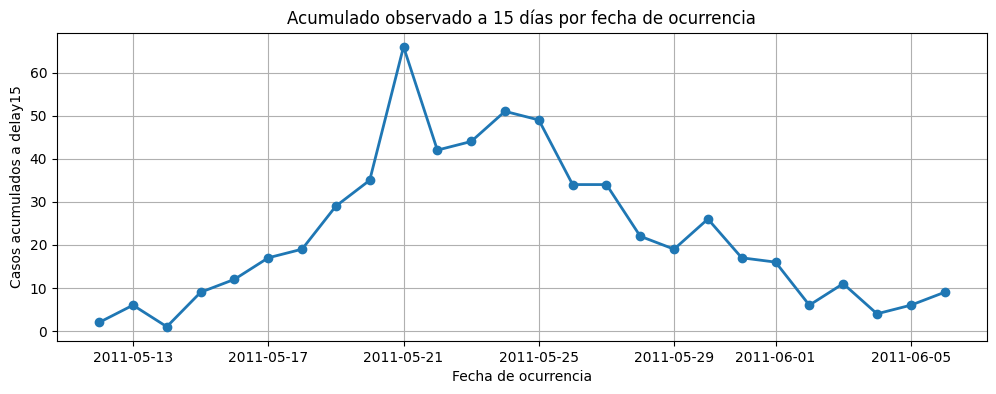

In [9]:

plt.figure(figsize=(12, 4))
plt.plot(df["date"], df["final_proxy_delay15"], marker="o", linewidth=2)
plt.title("Acumulado observado a 15 días por fecha de ocurrencia")
plt.xlabel("Fecha de ocurrencia")
plt.ylabel("Casos acumulados a delay15")
plt.show()


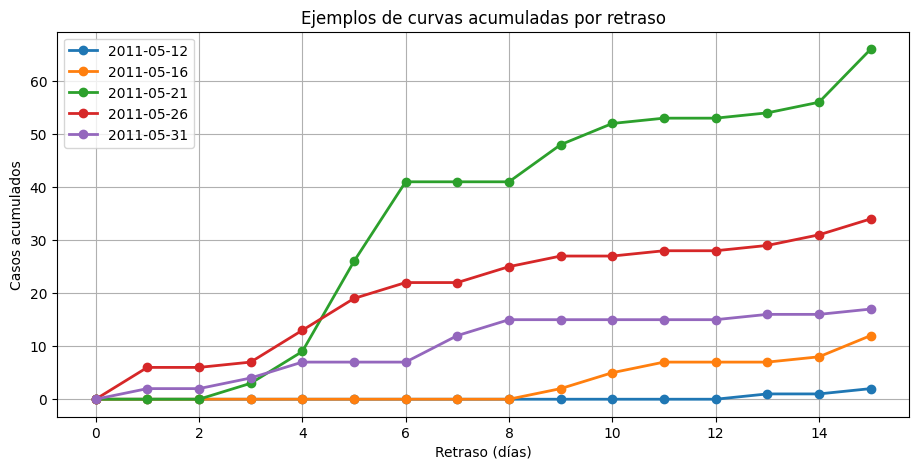

In [10]:

sample_idx = [0, 4, 9, 14, 19]
sample_idx = [i for i in sample_idx if i < len(df)]

plt.figure(figsize=(11, 5))
for i in sample_idx:
    row = df.loc[i, cols_delay].values
    plt.plot(range(D + 1), row, marker="o", linewidth=2, label=str(df.loc[i, "date"].date()))

plt.title("Ejemplos de curvas acumuladas por retraso")
plt.xlabel("Retraso (días)")
plt.ylabel("Casos acumulados")
plt.legend()
plt.show()



## 4. Curvas paramétricas: Exponencial vs Gompertz

El paper reporta que, para HUS, la **Gompertz** describe mejor la completitud acumulada que la exponencial.  
Aquí repetimos una comparación práctica sobre un período corto de calibración: **20 de mayo a 27 de mayo de 2011**.


In [11]:

def q_exponential(d, phi, b):
    d = np.asarray(d, dtype=float)
    phi = np.clip(phi, 1e-8, 0.999999)
    b = max(float(b), 1e-8)
    return 1 - (1 - phi) * np.exp(-b * d)

def q_gompertz(d, phi, b):
    d = np.asarray(d, dtype=float)
    phi = np.clip(phi, 1e-8, 0.999999)
    b = max(float(b), 1e-8)
    return np.exp(np.log(phi) * np.exp(-b * d))

def pooled_completion(train_df, D=15):
    total_final = train_df[f"delay{D}"].sum()
    q = np.array(
        [train_df[f"delay{h}"].sum() / total_final if total_final > 0 else np.nan for h in range(D + 1)],
        dtype=float
    )
    q = np.maximum.accumulate(np.clip(q, 1e-8, 0.999999))
    return q

def fit_curve(q_emp, kind="gompertz"):
    delays = np.arange(len(q_emp))
    p0 = [max(float(q_emp[0]), 1e-3), 0.3]

    if kind == "gompertz":
        func = q_gompertz
    elif kind == "exponential":
        func = q_exponential
    else:
        raise ValueError("kind debe ser 'gompertz' o 'exponential'")

    params, _ = curve_fit(
        func,
        delays,
        q_emp,
        p0=p0,
        bounds=([1e-8, 1e-8], [0.999999, 4]),
        maxfev=50000
    )

    q_fit = func(delays, *params)

    n = len(q_emp)
    k = 2
    rss = float(np.sum((q_emp - q_fit) ** 2))
    aic = n * np.log(rss / n + 1e-12) + 2 * k
    bic = n * np.log(rss / n + 1e-12) + k * np.log(n)

    return {
        "params": params,
        "q_fit": q_fit,
        "rss": rss,
        "aic": aic,
        "bic": bic
    }


In [12]:

calib = df[(df["date"] >= "2011-05-20") & (df["date"] <= "2011-05-27")].copy()
q_emp = pooled_completion(calib, D=D)

fit_exp = fit_curve(q_emp, kind="exponential")
fit_gom = fit_curve(q_emp, kind="gompertz")

comparison = pd.DataFrame({
    "Modelo": ["Exponencial", "Gompertz"],
    "RSS / SSE": [fit_exp["rss"], fit_gom["rss"]],
    "AIC aprox.": [fit_exp["aic"], fit_gom["aic"]],
    "BIC aprox.": [fit_exp["bic"], fit_gom["bic"]],
    "phi": [fit_exp["params"][0], fit_gom["params"][0]],
    "b": [fit_exp["params"][1], fit_gom["params"][1]],
}).sort_values("RSS / SSE")

comparison


,Modelo,RSS / SSE,AIC aprox.,BIC aprox.,phi,b
1,Gompertz,0.019175,-103.628114,-102.082937,2.650756e-02,0.258701
0,Exponencial,0.096085,-77.841740,-76.296563,1.000000e-08,0.123137


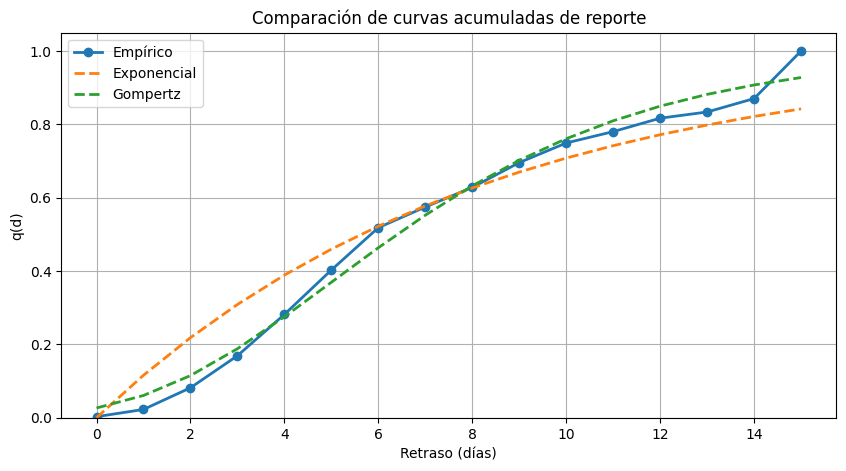

In [13]:

delays = np.arange(D + 1)

plt.figure(figsize=(10, 5))
plt.plot(delays, q_emp, marker="o", linewidth=2, label="Empírico")
plt.plot(delays, fit_exp["q_fit"], linestyle="--", linewidth=2, label="Exponencial")
plt.plot(delays, fit_gom["q_fit"], linestyle="--", linewidth=2, label="Gompertz")
plt.title("Comparación de curvas acumuladas de reporte")
plt.xlabel("Retraso (días)")
plt.ylabel("q(d)")
plt.ylim(0, 1.05)
plt.legend()
plt.show()



## 5. Aproximación deslizante en el tiempo

El paper permite que la probabilidad acumulada de reporte cambie con el tiempo, es decir, usa \(q_t(d)\) en lugar de una sola curva fija.  
Aquí aproximamos esa idea con una **ventana deslizante** de tamaño pequeño sobre fechas de ocurrencia consecutivas.

### Importante
Esta parte es **retrospectiva**:

- ajusta una curva Gompertz local para cada fecha usando una ventana corta;
- usa `delay15` como **proxy observacional de referencia**;
- sirve para capturar que el mecanismo de reporte **no es constante** a lo largo del brote.

No reemplaza al modelo bayesiano jerárquico completo del paper, pero sí te acerca bastante en la lógica.


In [14]:

def rolling_gompertz_params(full_df, D=15, window_size=7, n_boot=200, seed=123):
    rng = np.random.default_rng(seed)
    delay_arr = np.arange(D + 1)
    records = []

    for i, dt in enumerate(full_df["date"]):
        win = full_df.iloc[max(0, i - window_size + 1):i + 1].copy()
        total_proxy = win[f"delay{D}"].sum()

        if total_proxy <= 0:
            continue

        q_emp = pooled_completion(win, D=D)
        p0 = [max(float(q_emp[0]), 1e-3), 0.3]

        try:
            params, _ = curve_fit(
                q_gompertz,
                delay_arr,
                q_emp,
                p0=p0,
                bounds=([1e-8, 1e-8], [0.999999, 4]),
                maxfev=50000
            )
        except Exception:
            params = np.array([p0[0], 0.25])

        phi, b = params
        q_fit = q_gompertz(delay_arr, phi, b)

        rec = {
            "date": dt,
            "phi": float(phi),
            "b": float(b),
            "window_rows": len(win),
            "sse": float(np.sum((q_emp - q_fit) ** 2))
        }

        for h, val in enumerate(q_fit):
            rec[f"q{h}"] = float(val)

        # Bootstrap de filas de la ventana para bandas aproximadas de q_t(d)
        q_boot = {h: [] for h in range(D + 1)}
        idx = np.arange(len(win))

        for _ in range(n_boot):
            bs = win.iloc[rng.choice(idx, size=len(win), replace=True)]
            q_bs = pooled_completion(bs, D=D)
            p0_bs = [max(float(q_bs[0]), 1e-3), 0.3]

            try:
                params_bs, _ = curve_fit(
                    q_gompertz,
                    delay_arr,
                    q_bs,
                    p0=p0_bs,
                    bounds=([1e-8, 1e-8], [0.999999, 4]),
                    maxfev=50000
                )
            except Exception:
                params_bs = np.array([p0_bs[0], 0.25])

            q_fit_bs = q_gompertz(delay_arr, *params_bs)

            for h in range(D + 1):
                q_boot[h].append(float(np.clip(q_fit_bs[h], 1e-3, 0.999)))

        for h in range(D + 1):
            rec[f"q{h}_p10"] = np.quantile(q_boot[h], 0.10)
            rec[f"q{h}_p90"] = np.quantile(q_boot[h], 0.90)

        records.append(rec)

    return pd.DataFrame(records)


In [15]:

params_df = rolling_gompertz_params(df, D=D, window_size=7, n_boot=150)
params_df.head()


,date,phi,b,window_rows,sse,q0,q1,q2,q3,q4,q5,q6,q7,q8,q9,q10,q11,q12,q13,q14,q15,q0_p10,q0_p90,q1_p10,q1_p90,q2_p10,q2_p90,q3_p10,q3_p90,q4_p10,q4_p90,q5_p10,q5_p90,q6_p10,q6_p90,q7_p10,q7_p90,q8_p10,q8_p90,q9_p10,q9_p90,q10_p10,q10_p90,q11_p10,q11_p90,q12_p10,q12_p90,q13_p10,q13_p90,q14_p10,q14_p90,q15_p10,q15_p90
0,2011-05-12,1.000000e-08,0.228653,1,0.395366,1.000000e-08,4.316786e-07,0.000009,0.000094,0.000623,0.002817,0.009355,0.024308,0.051963,0.095104,0.153833,0.225534,0.305782,0.389575,0.472359,0.550617,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001000,0.001000,0.002817,0.002817,0.009355,0.009355,0.024308,0.024308,0.051963,0.051963,0.095104,0.095104,0.153833,0.153833,0.225534,0.225534,0.305782,0.305782,0.389575,0.389575,0.472359,0.472359,0.550617,0.550617
1,2011-05-13,1.000000e-08,0.259131,2,0.224589,1.000000e-08,6.702351e-07,0.000017,0.000210,0.001454,0.006460,0.020423,0.049647,0.098535,0.167237,0.251552,0.344708,0.439584,0.530307,0.612931,0.685395,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001000,0.001905,0.002817,0.008374,0.009355,0.025937,0.024308,0.061497,0.051963,0.118893,0.095104,0.196689,0.153833,0.288883,0.225534,0.387438,0.305782,0.484782,0.389575,0.575280,0.472359,0.655604,0.550617,0.724412
2,2011-05-14,1.000000e-08,0.262702,3,0.251062,1.000000e-08,7.050734e-07,0.000019,0.000230,0.001595,0.007063,0.022179,0.053467,0.105180,0.176968,0.264030,0.359144,0.455003,0.545787,0.627738,0.699033,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001000,0.002165,0.004015,0.009456,0.013094,0.028986,0.033148,0.067879,0.068775,0.129563,0.122038,0.211720,0.191515,0.307460,0.272887,0.408206,0.360426,0.506278,0.448500,0.596249,0.532560,0.675142,0.609524,0.741982
3,2011-05-15,1.000000e-08,0.290100,4,0.203653,1.000000e-08,1.033933e-06,0.000033,0.000446,0.003113,0.013316,0.039508,0.089136,0.163849,0.258378,0.363292,0.468801,0.567332,0.654371,0.728118,0.788680,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001444,0.004708,0.006417,0.019539,0.020295,0.055569,0.049365,0.119728,0.098040,0.210388,0.166504,0.318290,0.250603,0.431389,0.343599,0.539319,0.438388,0.635427,0.529097,0.716754,0.611765,0.783038,0.684314,0.835590
4,2011-05-16,1.000000e-08,0.290094,5,0.131756,1.000000e-08,1.033842e-06,0.000033,0.000446,0.003112,0.013314,0.039503,0.089127,0.163833,0.258358,0.363269,0.468776,0.567308,0.654348,0.728097,0.788662,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001,0.001848,0.004343,0.008134,0.018141,0.025257,0.052044,0.060056,0.113180,0.116457,0.200669,0.193219,0.306070,0.284551,0.417803,0.382548,0.525530,0.479677,0.622354,0.570262,0.704975,0.650894,0.772824,0.720148,0.826986


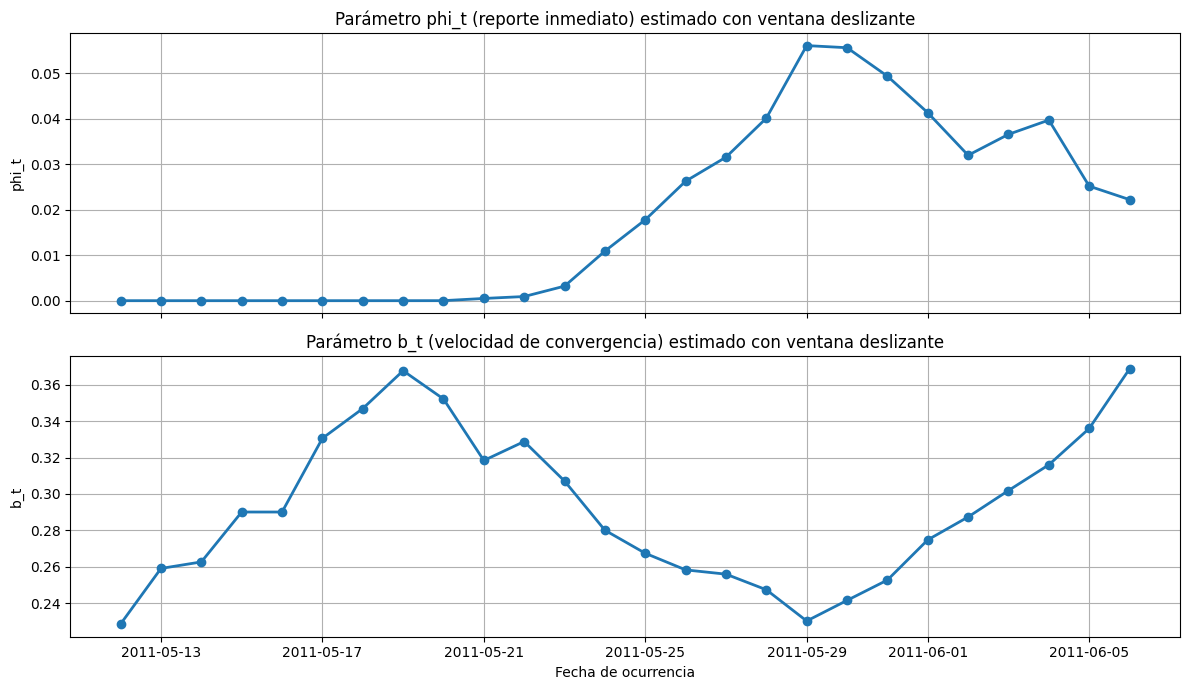

In [16]:

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(params_df["date"], params_df["phi"], marker="o", linewidth=2)
axes[0].set_title("Parámetro phi_t (reporte inmediato) estimado con ventana deslizante")
axes[0].set_ylabel("phi_t")

axes[1].plot(params_df["date"], params_df["b"], marker="o", linewidth=2)
axes[1].set_title("Parámetro b_t (velocidad de convergencia) estimado con ventana deslizante")
axes[1].set_ylabel("b_t")
axes[1].set_xlabel("Fecha de ocurrencia")

plt.tight_layout()
plt.show()


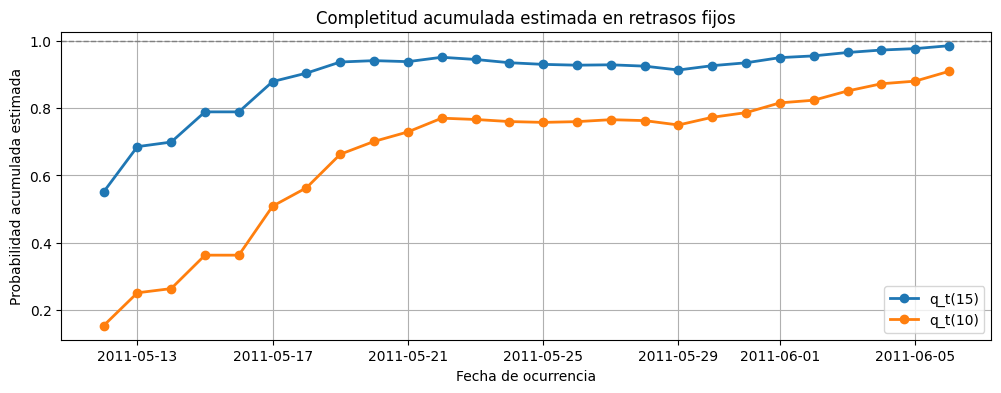

In [17]:

plt.figure(figsize=(12, 4))
plt.plot(params_df["date"], params_df["q15"], marker="o", linewidth=2, label="q_t(15)")
plt.plot(params_df["date"], params_df["q10"], marker="o", linewidth=2, label="q_t(10)")
plt.axhline(1.0, linestyle="--", linewidth=1, color="gray")
plt.title("Completitud acumulada estimada en retrasos fijos")
plt.xlabel("Fecha de ocurrencia")
plt.ylabel("Probabilidad acumulada estimada")
plt.legend()
plt.show()



## 6. Nowcasting retrospectivo con curva Gompertz deslizante

Para una fecha de evaluación `eval_date`, observamos para cada fecha de ocurrencia `t` solo el acumulado disponible hasta el retraso:

\[
h = \min(eval\_date - t, D)
\]

Luego usamos la curva local \(q_t(d)\) estimada con la ventana deslizante y calculamos:

\[
\widehat{N}_t = \frac{Y_{t,h}}{q_t(h)}
\]

donde:

- \(Y_{t,h}\) es el acumulado observado a esa fecha;
- \(q_t(h)\) es la completitud acumulada estimada;
- la banda se obtiene usando bootstrap sobre la ventana deslizante.

> **Ojo:** como el paper señala que HUS puede no estar completamente reportado ni siquiera a 15 días, aquí `delay15` se interpreta como **proxy observacional**, no como verdad absoluta.


In [18]:

def retrospective_nowcast(eval_date, analysis_df, params_df, D=15):
    params_lookup = params_df.set_index("date")
    rows = []

    for _, row in analysis_df.iterrows():
        t = row["date"]

        if t > pd.Timestamp(eval_date):
            continue

        if t not in params_lookup.index:
            continue

        h = (pd.Timestamp(eval_date) - t).days

        if h < 0:
            continue

        h = min(h, D)

        current_reported = row[f"delay{h}"]
        proxy_final_delay15 = row[f"delay{D}"]

        q_hat = float(np.clip(params_lookup.loc[t, f"q{h}"], 1e-3, 0.999))
        q_p10 = float(np.clip(params_lookup.loc[t, f"q{h}_p10"], 1e-3, 0.999))
        q_p90 = float(np.clip(params_lookup.loc[t, f"q{h}_p90"], 1e-3, 0.999))

        nowcast_point = max(current_reported, current_reported / q_hat)

        # Menor q -> mayor total, por eso el orden se invierte
        nowcast_p10 = max(current_reported, current_reported / q_p90)
        nowcast_p90 = max(current_reported, current_reported / q_p10)

        rows.append({
            "eval_date": pd.Timestamp(eval_date),
            "occurrence_date": t,
            "available_delay": h,
            "current_reported": current_reported,
            "proxy_final_delay15": proxy_final_delay15,
            "nowcast_point": nowcast_point,
            "nowcast_p10": nowcast_p10,
            "nowcast_p90": nowcast_p90,
            "phi_t": params_lookup.loc[t, "phi"],
            "b_t": params_lookup.loc[t, "b"]
        })

    return pd.DataFrame(rows)


In [19]:

def plot_nowcast(eval_date, analysis_df, params_df, D=15):
    pred = retrospective_nowcast(eval_date, analysis_df, params_df, D=D)

    plt.figure(figsize=(12, 5))
    plt.plot(pred["occurrence_date"], pred["current_reported"], marker="o", linewidth=2, label="Casos reportados al corte")
    plt.plot(pred["occurrence_date"], pred["proxy_final_delay15"], marker="o", linewidth=2, linestyle="--", label="Acumulado observado a 15 días (proxy)")
    plt.plot(pred["occurrence_date"], pred["nowcast_point"], marker="o", linewidth=2, label="Nowcast Gompertz deslizante")

    plt.fill_between(
        pred["occurrence_date"],
        pred["nowcast_p10"],
        pred["nowcast_p90"],
        alpha=0.20,
        label="Banda bootstrap aprox. 80%"
    )

    plt.title(f"Nowcasting retrospectivo para la fecha de evaluación {pd.Timestamp(eval_date).date()}")
    plt.xlabel("Fecha de ocurrencia")
    plt.ylabel("Número de casos")
    plt.legend()
    plt.show()

    return pred



## 7. Fechas de evaluación alineadas con el paper

El artículo muestra resultados para cinco cortes temporales del brote HUS:

- 2011-05-25
- 2011-05-28
- 2011-05-31
- 2011-06-03
- 2011-06-06



### Fecha de evaluación: 2011-05-25


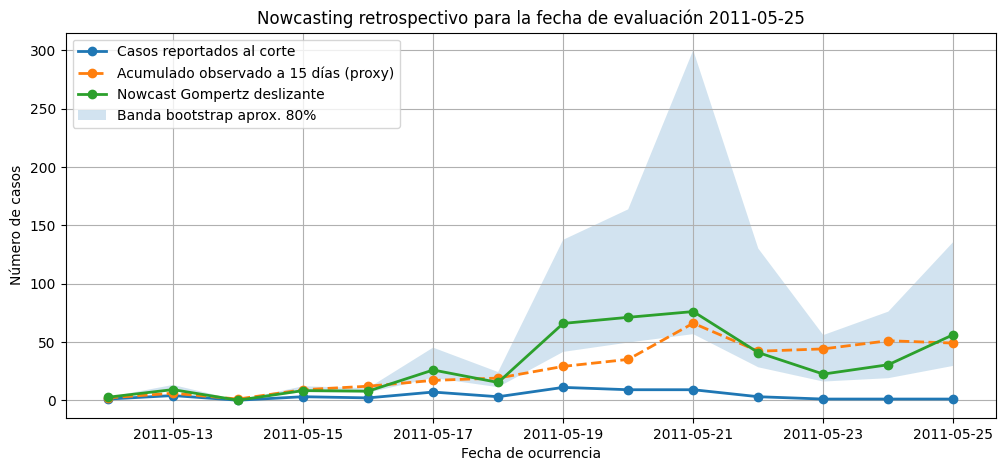

,eval_date,occurrence_date,available_delay,current_reported,proxy_final_delay15,nowcast_point,nowcast_p10,nowcast_p90,phi_t,b_t
6,2011-05-25,2011-05-18,7,3,19,15.230658,11.177669,24.152026,1.000000e-08,0.346879
7,2011-05-25,2011-05-19,6,11,29,65.839676,41.425957,137.483507,8.825678e-08,0.367637
8,2011-05-25,2011-05-20,5,9,35,71.073099,49.428449,163.619024,6.021498e-06,0.352148
9,2011-05-25,2011-05-21,4,9,66,76.003918,56.652727,300.031480,4.885104e-04,0.318382
10,2011-05-25,2011-05-22,3,3,42,40.842607,28.246612,130.061114,9.104746e-04,0.328785
11,2011-05-25,2011-05-23,2,1,44,22.398542,15.997738,55.827209,3.195864e-03,0.307093
12,2011-05-25,2011-05-24,1,1,51,30.435234,18.902594,75.950041,1.089183e-02,0.280101
13,2011-05-25,2011-05-25,0,1,49,56.247290,29.457494,135.722489,1.777863e-02,0.267457



### Fecha de evaluación: 2011-05-28


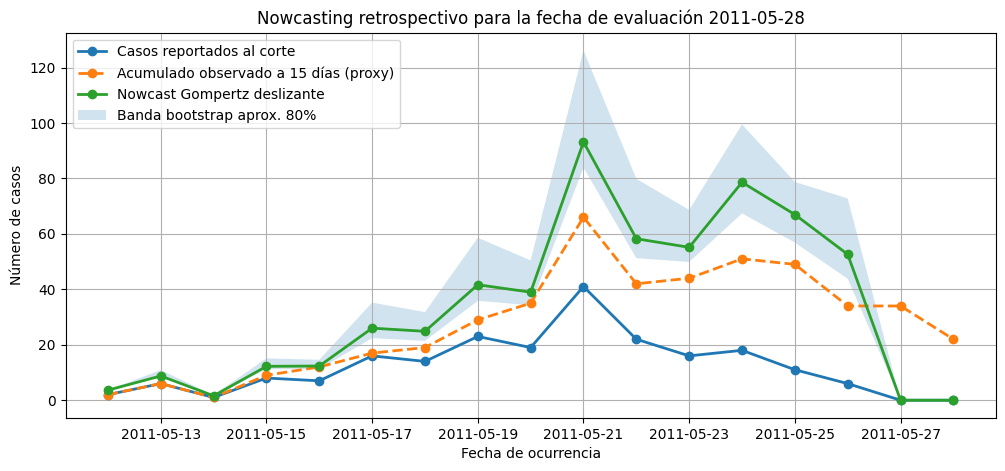

,eval_date,occurrence_date,available_delay,current_reported,proxy_final_delay15,nowcast_point,nowcast_p10,nowcast_p90,phi_t,b_t
9,2011-05-28,2011-05-21,7,41,66,93.174277,83.915385,126.247198,0.000489,0.318382
10,2011-05-28,2011-05-22,6,22,42,58.254147,51.239020,79.889571,0.000910,0.328785
11,2011-05-28,2011-05-23,5,16,44,55.146783,49.869256,68.639799,0.003196,0.307093
12,2011-05-28,2011-05-24,4,18,51,78.608035,67.375090,99.503389,0.010892,0.280101
13,2011-05-28,2011-05-25,3,11,49,66.973391,56.879319,78.746248,0.017779,0.267457
14,2011-05-28,2011-05-26,2,6,34,52.613272,43.807578,72.782215,0.026255,0.258337
15,2011-05-28,2011-05-27,1,0,34,0.000000,0.000000,0.000000,0.031535,0.255989
16,2011-05-28,2011-05-28,0,0,22,0.000000,0.000000,0.000000,0.040109,0.247427



### Fecha de evaluación: 2011-05-31


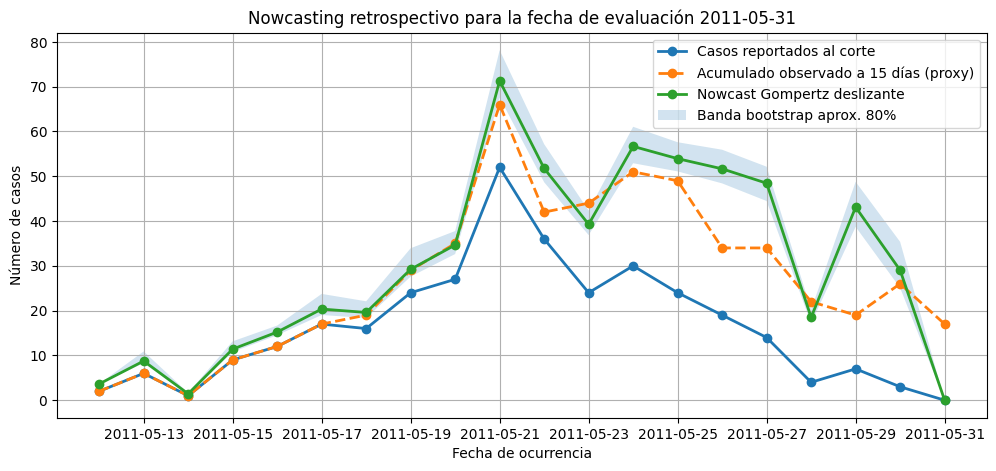

,eval_date,occurrence_date,available_delay,current_reported,proxy_final_delay15,nowcast_point,nowcast_p10,nowcast_p90,phi_t,b_t
12,2011-05-31,2011-05-24,7,30,51,56.678171,52.915895,61.050797,0.010892,0.280101
13,2011-05-31,2011-05-25,6,24,49,53.936105,51.090581,57.600508,0.017779,0.267457
14,2011-05-31,2011-05-26,5,19,34,51.661493,48.413844,55.929967,0.026255,0.258337
15,2011-05-31,2011-05-27,4,14,34,48.452668,44.472909,52.134889,0.031535,0.255989
16,2011-05-31,2011-05-28,3,4,22,18.490818,17.180196,20.194674,0.040109,0.247427
17,2011-05-31,2011-05-29,2,7,19,43.112953,38.714549,48.773697,0.056058,0.230287
18,2011-05-31,2011-05-30,1,3,26,29.024935,25.078558,35.357617,0.055590,0.241591
19,2011-05-31,2011-05-31,0,0,17,0.000000,0.000000,0.000000,0.049338,0.252764



### Fecha de evaluación: 2011-06-03


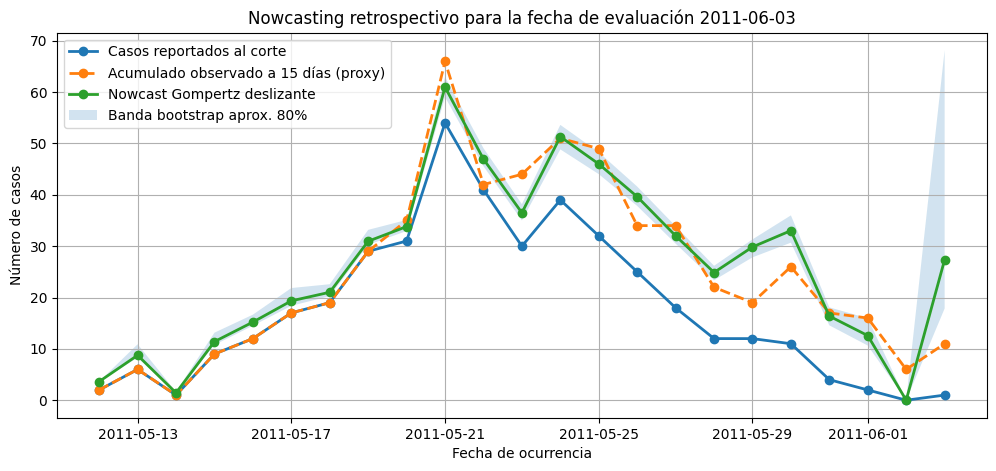

,eval_date,occurrence_date,available_delay,current_reported,proxy_final_delay15,nowcast_point,nowcast_p10,nowcast_p90,phi_t,b_t
15,2011-06-03,2011-05-27,7,18,34,32.020810,30.496908,33.887710,0.031535,0.255989
16,2011-06-03,2011-05-28,6,12,22,24.870821,23.360055,26.178912,0.040109,0.247427
17,2011-06-03,2011-05-29,5,12,19,29.842780,27.821351,31.320914,0.056058,0.230287
18,2011-06-03,2011-05-30,4,11,26,33.027462,30.678964,35.996557,0.055590,0.241591
19,2011-06-03,2011-05-31,3,4,17,16.378038,14.578832,18.085706,0.049338,0.252764
20,2011-06-03,2011-06-01,2,2,16,12.583198,10.647129,15.948763,0.041308,0.274823
21,2011-06-03,2011-06-02,1,0,6,0.000000,0.000000,0.000000,0.031954,0.287387
22,2011-06-03,2011-06-03,0,1,11,27.356026,17.858597,68.156598,0.036555,0.301897



### Fecha de evaluación: 2011-06-06


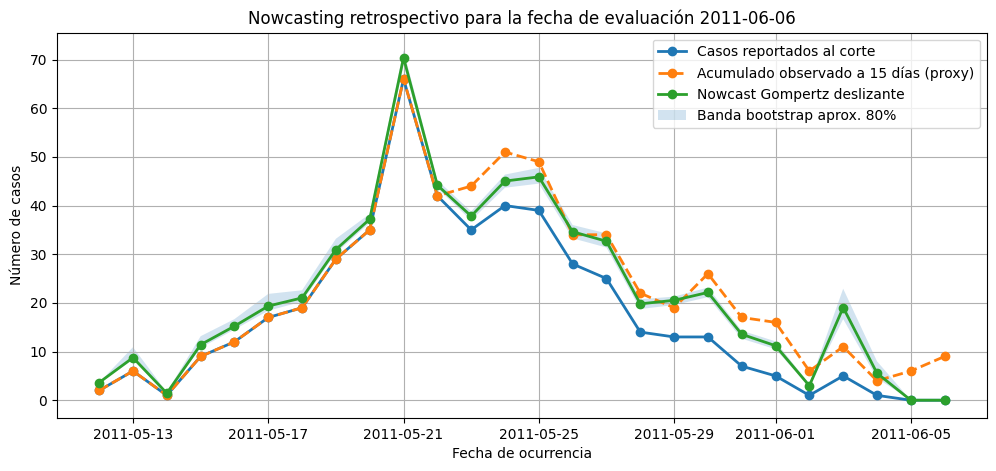

,eval_date,occurrence_date,available_delay,current_reported,proxy_final_delay15,nowcast_point,nowcast_p10,nowcast_p90,phi_t,b_t
18,2011-06-06,2011-05-30,7,13,26,22.143802,21.176850,23.153688,0.055590,0.241591
19,2011-06-06,2011-05-31,6,7,17,13.548585,12.641708,14.294408,0.049338,0.252764
20,2011-06-06,2011-06-01,5,5,16,11.199563,10.481610,12.094661,0.041308,0.274823
21,2011-06-06,2011-06-02,4,1,6,2.976701,2.704812,3.295067,0.031954,0.287387
22,2011-06-06,2011-06-03,3,5,11,19.050927,16.671610,22.912044,0.036555,0.301897
23,2011-06-06,2011-06-04,2,1,4,5.556556,4.531443,8.002928,0.039689,0.316026
24,2011-06-06,2011-06-05,1,0,6,0.000000,0.000000,0.000000,0.025170,0.335951
25,2011-06-06,2011-06-06,0,0,9,0.000000,0.000000,0.000000,0.022211,0.368661


In [20]:

eval_dates = [
    "2011-05-25",
    "2011-05-28",
    "2011-05-31",
    "2011-06-03",
    "2011-06-06"
]

predictions_by_eval = {}

for ed in eval_dates:
    print(f"\n### Fecha de evaluación: {ed}")
    pred = plot_nowcast(ed, df, params_df, D=D)
    predictions_by_eval[ed] = pred
    display(pred.tail(8))



## 8. Resumen numérico por fecha de evaluación

Aquí resumimos, para cada corte:

- cuántos casos se ven reportados en ese momento;
- cuánto sube el nowcast respecto a ese valor reportado;
- cuánto difiere del acumulado observado a 15 días, recordando que este último es solo un proxy.


In [21]:

summary_rows = []

for ed, pred in predictions_by_eval.items():
    recent = pred.tail(5).copy()

    summary_rows.append({
        "eval_date": ed,
        "media_reportado_al_corte_ult5": recent["current_reported"].mean(),
        "media_nowcast_ult5": recent["nowcast_point"].mean(),
        "media_proxy_delay15_ult5": recent["proxy_final_delay15"].mean(),
        "uplift_nowcast_vs_reportado_%": 100 * (
            (recent["nowcast_point"].mean() - recent["current_reported"].mean()) /
            max(recent["current_reported"].mean(), 1e-9)
        ),
        "uplift_proxy15_vs_reportado_%": 100 * (
            (recent["proxy_final_delay15"].mean() - recent["current_reported"].mean()) /
            max(recent["current_reported"].mean(), 1e-9)
        )
    })

summary_eval = pd.DataFrame(summary_rows)
summary_eval


,eval_date,media_reportado_al_corte_ult5,media_nowcast_ult5,media_proxy_delay15_ult5,uplift_nowcast_vs_reportado_%,uplift_proxy15_vs_reportado_%
0,2011-05-25,3.0,45.185518,50.4,1406.183940,1580.000000
1,2011-05-28,7.0,39.638940,38.0,466.270565,442.857143
2,2011-05-31,5.6,27.816275,23.6,396.719192,321.428571
3,2011-06-03,3.6,17.868945,15.2,396.359579,322.222222
4,2011-06-06,1.4,5.516837,7.2,294.059772,414.285714



## 9. Advertencia metodológica sobre métricas

En la aplicación HUS del paper, los autores indican que **no puede calcularse el error real final** porque el número eventual de casos verdaderos **no está disponible**, y además el reporte puede no estar completo ni siquiera a 15 días.

Por eso:

- comparar el nowcast contra `delay15` es útil solo como **referencia interna**;
- si el modelo permite \(q_t(15) < 1\), es normal que algunos nowcasts queden por encima de `delay15`;
- eso **no implica automáticamente** que el modelo esté mal, sino que está admitiendo **subreporte residual después del día 15**.


In [22]:

# Métricas SOLO contra el proxy delay15 (interpretar con cuidado)
proxy_frames = []

for ed, pred in predictions_by_eval.items():
    tmp = pred.copy()
    tmp["proxy_error"] = tmp["nowcast_point"] - tmp["proxy_final_delay15"]
    tmp["proxy_abs_error"] = tmp["proxy_error"].abs()
    tmp["proxy_pct_gap"] = np.where(
        tmp["proxy_final_delay15"] > 0,
        100 * tmp["proxy_error"] / tmp["proxy_final_delay15"],
        np.nan
    )
    tmp["eval_date"] = ed
    proxy_frames.append(tmp)

proxy_bt = pd.concat(proxy_frames, ignore_index=True)

proxy_metrics = pd.DataFrame({
    "Indicador": ["MAE vs proxy delay15", "Bias vs proxy delay15", "Gap porcentual medio vs proxy delay15"],
    "Valor": [
        proxy_bt["proxy_abs_error"].mean(),
        proxy_bt["proxy_error"].mean(),
        proxy_bt["proxy_pct_gap"].mean()
    ]
})

proxy_metrics


,Indicador,Valor
0,MAE vs proxy delay15,6.754682
1,Bias vs proxy delay15,2.508731
2,Gap porcentual medio vs proxy delay15,13.565244



## 10. Conclusión automática para tu informe

Este bloque te genera un párrafo base que puedes llevar a la sección **Results** o **Conclusion and discussion**.


In [23]:

gompertz_better = comparison.sort_values("RSS / SSE").iloc[0]["Modelo"] == "Gompertz"
avg_q15 = params_df["q15"].mean()
avg_uplift = summary_eval["uplift_nowcast_vs_reportado_%"].mean()
avg_proxy_gap = proxy_bt["proxy_pct_gap"].mean()

conclusion_text = f'''
Conclusión automática del notebook:

La base HUS fue tratada correctamente como una matriz de reportes acumulados por retraso.
En la comparación paramétrica sobre el período corto de calibración, la curva {"Gompertz" if gompertz_better else "Exponencial"} presentó el mejor ajuste agregado.
Además, los parámetros locales phi_t y b_t variaron a lo largo del período, lo que respalda la idea de que el mecanismo de reporte no fue constante en el tiempo.

Bajo la aproximación deslizante, la completitud acumulada promedio estimada en d=15 fue de {avg_q15:.3f}, lo que sugiere que el día 15 no necesariamente representa reporte completo.
En promedio, el nowcast elevó los casos observados al corte en {avg_uplift:.2f}% para las últimas fechas observadas de cada evaluación.

Si se compara contra delay15 como proxy observacional, el gap porcentual medio fue de {avg_proxy_gap:.2f}%.
Sin embargo, esta comparación debe interpretarse con cautela, porque el enfoque adoptado permite q_t(15) < 1 y, por tanto, admite subreporte residual después del retraso máximo observado.

En conjunto, los resultados son coherentes con la literatura reciente para HUS:
una curva Gompertz y una estructura temporal cambiante producen nowcasts más plausibles que un mecanismo de reporte fijo.
'''
print(conclusion_text)



Conclusión automática del notebook:

La base HUS fue tratada correctamente como una matriz de reportes acumulados por retraso.
En la comparación paramétrica sobre el período corto de calibración, la curva Gompertz presentó el mejor ajuste agregado.
Además, los parámetros locales phi_t y b_t variaron a lo largo del período, lo que respalda la idea de que el mecanismo de reporte no fue constante en el tiempo.

Bajo la aproximación deslizante, la completitud acumulada promedio estimada en d=15 fue de 0.893, lo que sugiere que el día 15 no necesariamente representa reporte completo.
En promedio, el nowcast elevó los casos observados al corte en 591.92% para las últimas fechas observadas de cada evaluación.

Si se compara contra delay15 como proxy observacional, el gap porcentual medio fue de 13.57%.
Sin embargo, esta comparación debe interpretarse con cautela, porque el enfoque adoptado permite q_t(15) < 1 y, por tanto, admite subreporte residual después del retraso máximo observado.

En 